In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
import numpy as np
import pandas as pd

In [3]:
import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft

In [4]:
# --- carga de datos ---
path_json = "../tmp/NMC-20.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 301


In [5]:
# --- Selección de ciclos ---
ciclos_sel = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    rango=(21, 900),
    excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 288 ciclos seleccionados
   → [21, 24, 27, 33, 36, 39, 42, 45, 48, 51]...


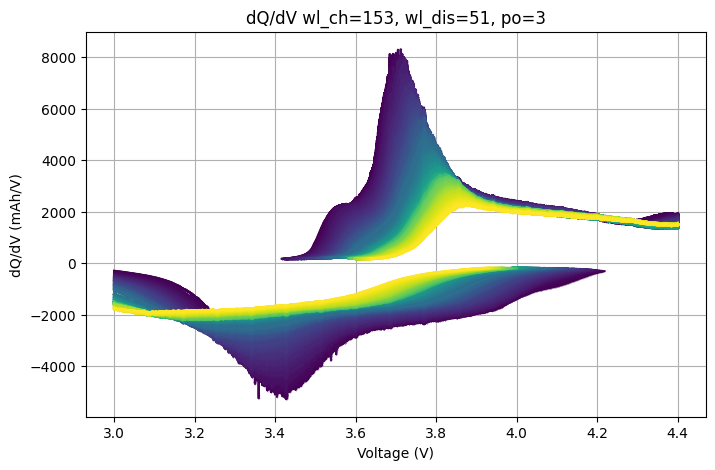

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...: {...}}\n"

In [15]:
# --- Trunco datos y calculo derivada ---

# Para NMC-20:
# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
# Esto se debe a que la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

diccio = dr.truncar_señal(ciclos_sel, dict_ciclos_sep, n_dis=10, n_ch=30)
diccio =  dr.plot_dqdV(ciclos_sel, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...: {...}}
'''
# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

In [44]:
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [ ]:
def plot_n_cycles(indices_ciclos, diccio, x, y, nombre_grafico='plot', scatter=False):
    """
    Grafica múltiples ciclos (carga y descarga) de un diccionario:
        diccio[ciclo]['Ch'], diccio[ciclo]['Dis']

    Parámetros
    ----------
    indices_ciclos : list[int]
        Ciclos a graficar.
    diccio : dict
        Diccionario con DataFrames por ciclo y por modo ('Ch', 'Dis').
    x, y : str
        Nombres de las columnas a graficar.
    nombre_grafico : str, opcional
        Nombre base del archivo de salida.
    scatter : bool, opcional
        Si True, usa puntos en lugar de líneas.
    """

    plt.figure(figsize=(8,5))
    colors = cm.viridis(np.linspace(0, 1, len(indices_ciclos)))

    for i, color in zip(indices_ciclos, colors):
        df_ch = diccio[i]['Ch']
        df_dis = diccio[i]['Dis']

        # --- Detectar nombre de columna equivalente para descarga ---
        x_dis_key = x.replace('_ch_', '_dis_') if '_ch_' in x else x
        y_dis_key = y.replace('_ch_', '_dis_') if '_ch_' in y else y

        # --- Extraer datos ---
        x_ch = df_ch[x].values
        y_ch = df_ch[y].values

        x_dis = df_dis[x_dis_key].values
        y_dis = df_dis[y_dis_key].values

        # --- Graficar ---
        if scatter:
            plt.scatter(x_ch, y_ch, s=2, color=color, label=f'Ciclo {i} (Ch)')
            plt.scatter(x_dis, y_dis, s=2, color=color, marker='x', label=f'Ciclo {i} (Dis)')
        else:
            plt.plot(x_ch, y_ch, color=color, linewidth=1, label=f'Ciclo {i} (Ch)')
            plt.plot(x_dis, y_dis, color=color, linestyle='-', linewidth=1, label=f'Ciclo {i} (Dis)')

    # --- Etiquetas ---
    labels_con_unidades = {
        'Time': 'Time (h)',
        'Q': 'Capacity (mAh)',
        'CellV': 'Cell Voltage (V)',
        'dCapacity/dCellV': 'dQ/dV (mAh/V)',
        'dCellV/dCapacity': 'dV/dQ (V/mAh)',
        'dqdv_ch_calc': 'dQ/dV (mAh/V)',
        'dqdv_dis_calc': 'dQ/dV (mAh/V)',
        'Current': 'Current (A)',
    }

    plt.xlabel(labels_con_unidades.get(x, x), fontsize=14)
    plt.ylabel(labels_con_unidades.get(y, y), fontsize=14)
    plt.title(f'{y} vs {x}', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    #plt.legend(fontsize=10, ncol=2)
    plt.tight_layout()
    plt.savefig(f'../output/{nombre_grafico}_{y}_vs_{x}.png', dpi=300)
    plt.show()

In [101]:
def plot_n_cycles_poster(indices_ciclos, diccio, x, y, nombre_grafico='plot_poster', scatter=False):
    """
    Versión para póster científico (~15x10 cm).
    Gráfica ciclos de carga y descarga con estilo visual limpio.
    """
    # --- Tamaño 15x10 cm ≈ 6x4 pulgadas ---
    plt.figure(figsize=(3.8, 3))
    colors = cm.viridis(np.linspace(0, 1, len(indices_ciclos)))

    for i, color in zip(indices_ciclos, colors):
        df_ch = diccio[i]['Ch']
        df_dis = diccio[i]['Dis']

        # --- Detectar claves equivalentes para descarga ---
        x_dis_key = x.replace('_ch_', '_dis_') if '_ch_' in x else x
        y_dis_key = y.replace('_ch_', '_dis_') if '_ch_' in y else y

        # --- Extraer datos ---
        x_ch, y_ch = df_ch[x].values, df_ch[y].values
        x_dis, y_dis = df_dis[x_dis_key].values, df_dis[y_dis_key].values

        # --- Graficar ---
        #           [21, 99, 198, 297, 396, 498, 597, 696, 795, 894]
        if i not in []:#[21, 99, 198, 198, 297, 498, 597, 696, 894]:
            plt.plot(x_ch, y_ch, color=color, linewidth=1.5)
            #plt.plot(x_dis, y_dis, color=color, linestyle='-', linewidth=1.2)

    # --- Etiquetas elegantes ---
    labels_con_unidades = {
        'Time': 'Time (h)',
        'Q': 'Capacity (mAh)',
        'CellV': 'Voltaje (V)',
        'dCapacity/dCellV': '$dQ/dV$ (mAh/V)',
        'dCellV/dCapacity': 'dV/dQ (V/mAh)',
        'dqdv_ch_calc': 'dQ/dV (Ah/V)',
        'dqdv_dis_calc': 'dQ/dV (mAh/V)',
        'Current': 'Current (A)',
    }

    # Crear colorbar asociada a los ciclos
    norm = mcolors.Normalize(vmin=min(indices_ciclos), vmax=max(indices_ciclos))
    sm = cm.ScalarMappable(cmap=cm.viridis, norm=norm)
    sm.set_array([])  # requerido
    cbar = plt.colorbar(sm, ax=plt.gca(), ticks=indices_ciclos[::2])
    cbar.set_label('Número de ciclo')


    plt.xlabel(labels_con_unidades.get(x, x), fontsize=16)
    plt.ylabel(labels_con_unidades.get(y, y), fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    plt.ylabel(labels_con_unidades.get(y, y), fontsize=16)
    
    # --- Estilo minimalista ---
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    #plt.box(False)  # quita el recuadro
    plt.savefig(f'../output/{nombre_grafico}_{y}_vs_{x}.png', dpi=600, bbox_inches='tight')
    plt.show()


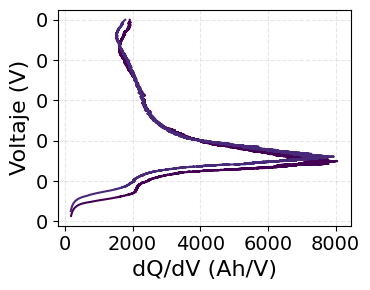

In [90]:
ciclos_graficar = [21, 99, 198, 297, 396, 498, 597, 696, 795, 894]

plot_n_cycles_poster(ciclos_graficar, diccio, 'dqdv_ch_calc', 'CellV', nombre_grafico='plot', scatter=False)

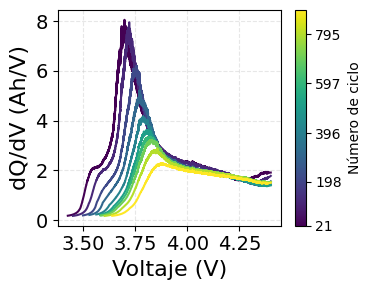

In [102]:
ciclos_graficar = [21, 99, 198, 297, 396, 498, 597, 696, 795, 894]

plot_n_cycles_poster(ciclos_graficar, diccio, 'CellV', 'dqdv_ch_calc', nombre_grafico='plot', scatter=False)